**PySpark Session Setup**

In [2]:
# install PySpark
! pip install pyspark >& /dev/null

#start session
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("wheat_futures_price_prediction").getOrCreate()

#upload libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

25/04/23 00:24:36 WARN Utils: Your hostname, Presleys-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 10.1.59.35 instead (on interface en0)
25/04/23 00:24:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/23 00:24:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
#Read weather and pricing data
weather_raw = spark.read.csv('weather_data_RAW.csv', header=True, inferSchema=True)
wheat_price_data = spark.read.csv('US_wheat_future_pricing_RAW.csv', header=True, inferSchema=True)

#Parse date columns
from pyspark.sql.functions import to_date, col

weather = weather_raw.withColumn(
    "Date",
    to_date(col("datetime"), "M/d/yyyy")      
).drop("datetime")                            

pricing = wheat_price_data.withColumn(
    "Date",
    to_date(col("Date"), "M/d/yyyy")        
)

#Join on Date
merged = weather.join(pricing, on="Date", how="left")

merged.show(10, truncate=False)


+----------+-----+-------+-------+----+------------+------------+---------+----+--------+------+----------+-----------+----------+----+---------+--------+---------+-------+----------------+----------+----------+--------------+-----------+-------+----------+-------------------+-------------------+---------+----------------------------+--------------------------------------------------------------------------------+-----------------+----------------------------------------------------------+------+------+------+------+------+--------+
|Date      |name |tempmax|tempmin|temp|feelslikemax|feelslikemin|feelslike|dew |humidity|precip|precipprob|precipcover|preciptype|snow|snowdepth|windgust|windspeed|winddir|sealevelpressure|cloudcover|visibility|solarradiation|solarenergy|uvindex|severerisk|sunrise            |sunset             |moonphase|conditions                  |description                                                                     |icon             |stations                  


EDA

+------------+------------+---------------+---------------+------------+--------------------+--------------------+-----------------+-----------+----------------+--------------+------------------+-------------------+------------------+------------+-----------------+----------------+-----------------+---------------+------------------------+------------------+------------------+----------------------+-------------------+---------------+------------------+---------------+--------------+-----------------+------------------+-------------------+------------+----------------+-------------+------------+------------+-----------+-----------+----------------+
|Date_missing|name_missing|tempmax_missing|tempmin_missing|temp_missing|feelslikemax_missing|feelslikemin_missing|feelslike_missing|dew_missing|humidity_missing|precip_missing|precipprob_missing|precipcover_missing|preciptype_missing|snow_missing|snowdepth_missing|windgust_missing|windspeed_missing|winddir_missing|sealevelpressure_missing|cl

+-------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------+-------------------+-----------------+-----------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+----------------------------+----------------------------------------------------------------------------------+---------+-----------------------------+------------------+------------------+------------------+------------------+------+--------+
|summary|name             |tempmax           |tempmin           |temp              |feelslikemax      |feelslikemin      |feelslike         |dew               |humidity          |precip             |precipprob        |precipcover       |preciptype  |snow        

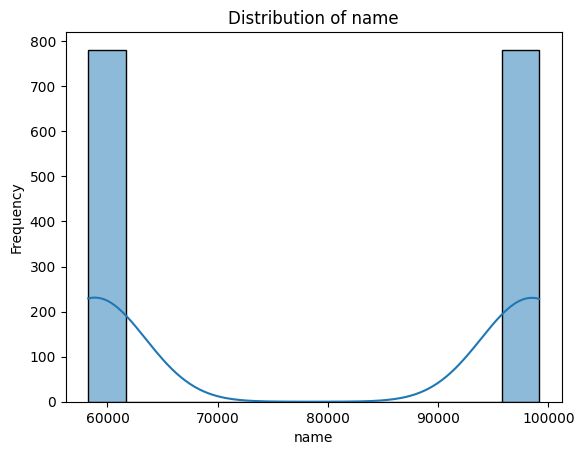

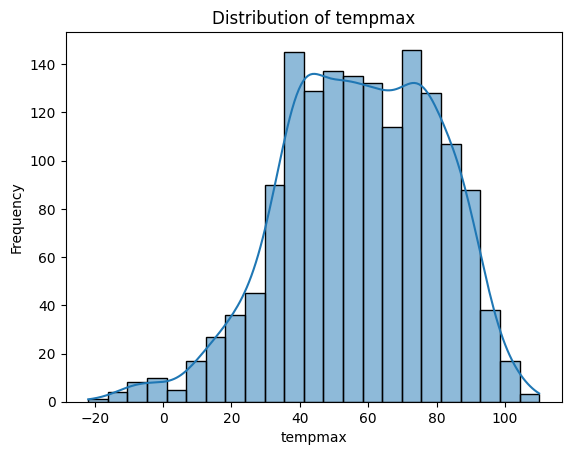

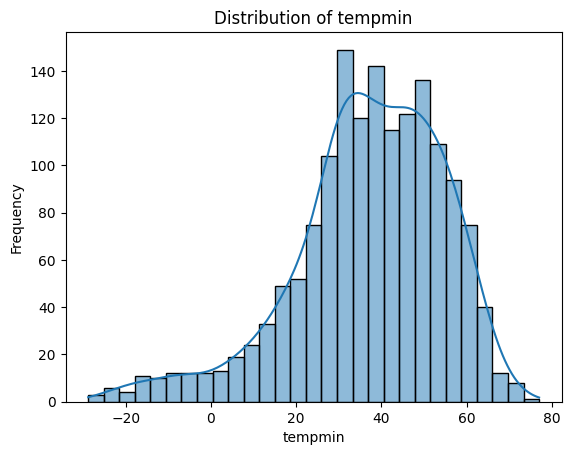

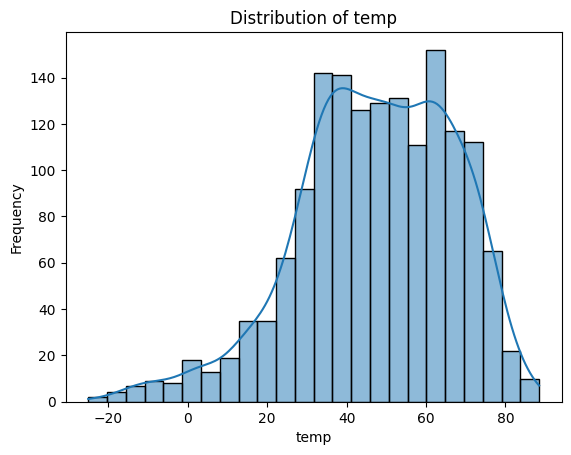

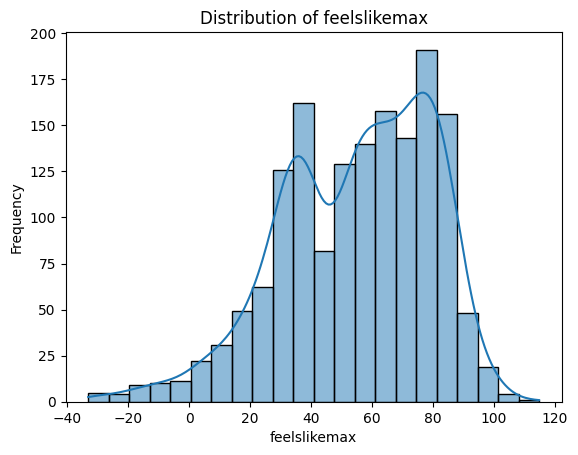

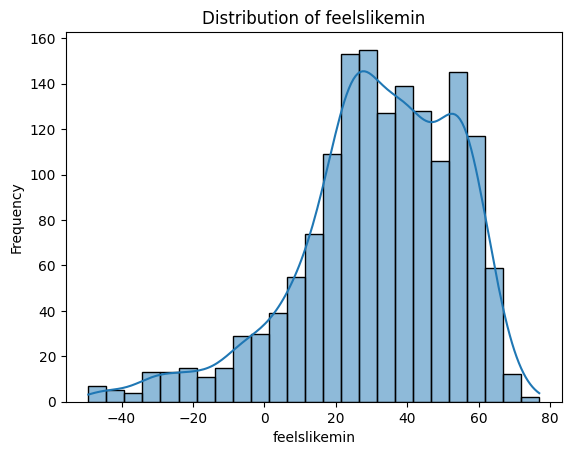

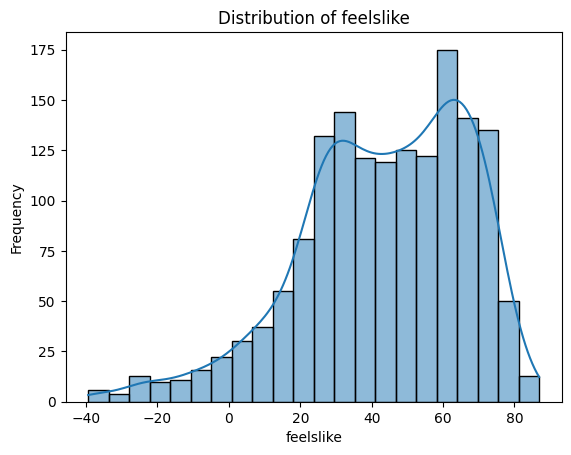

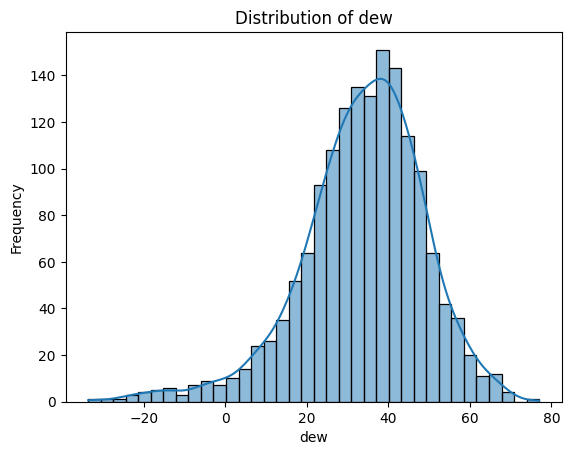

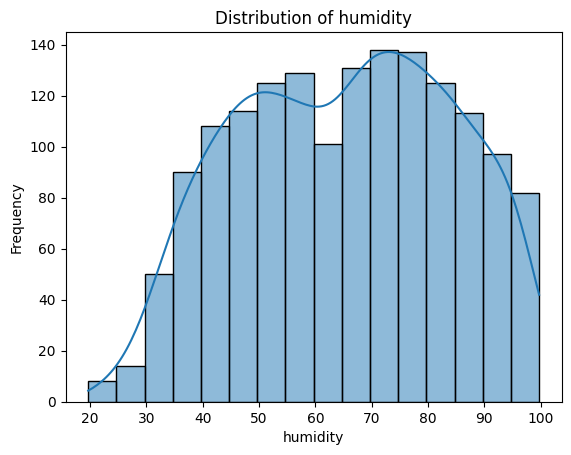

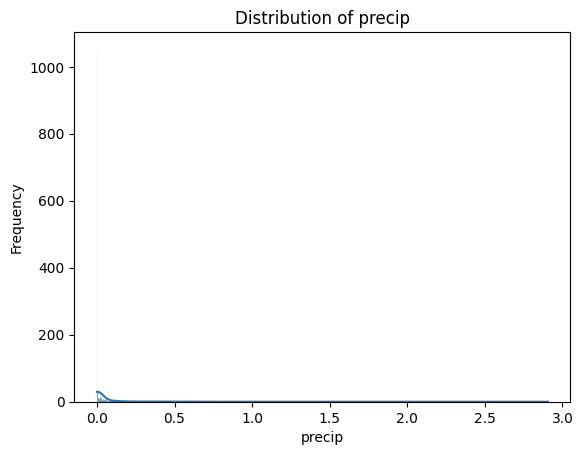

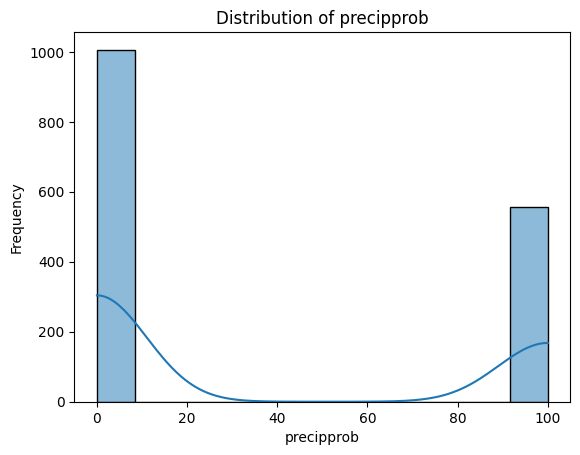

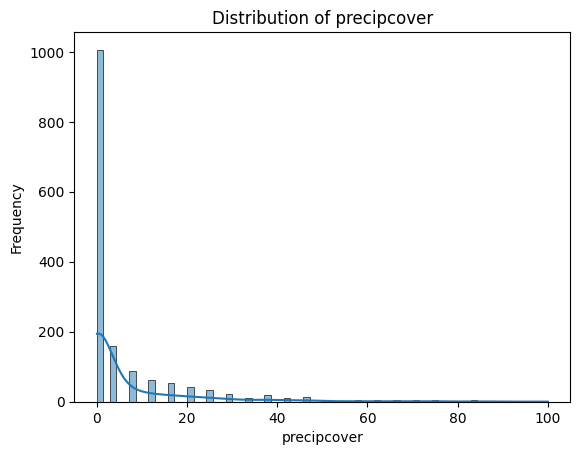

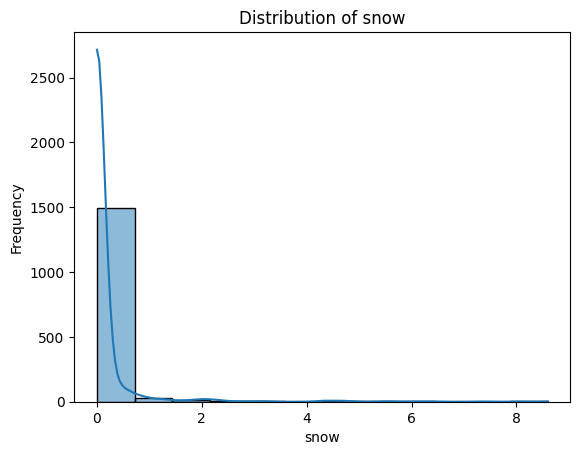

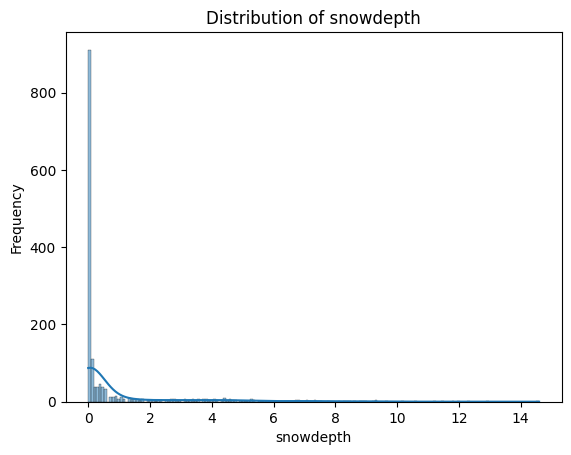

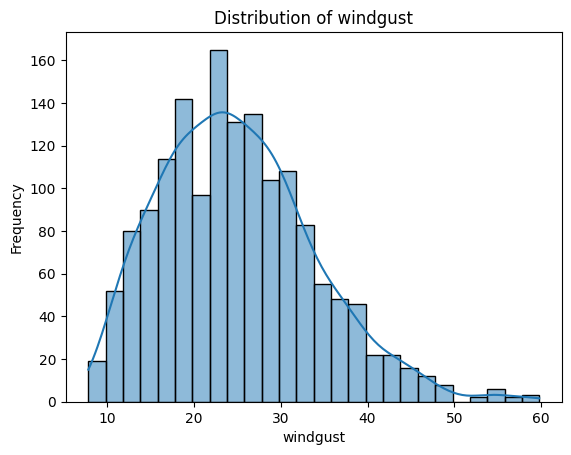

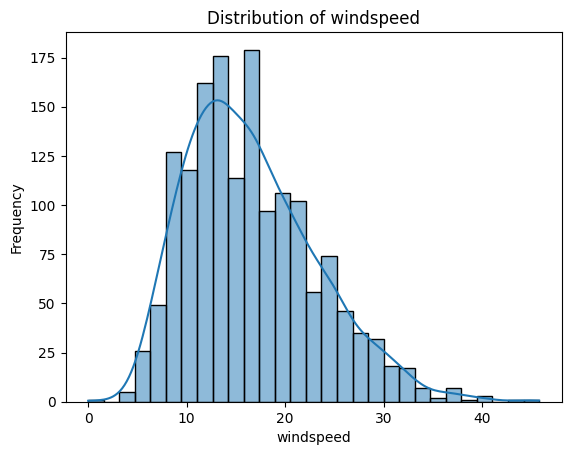

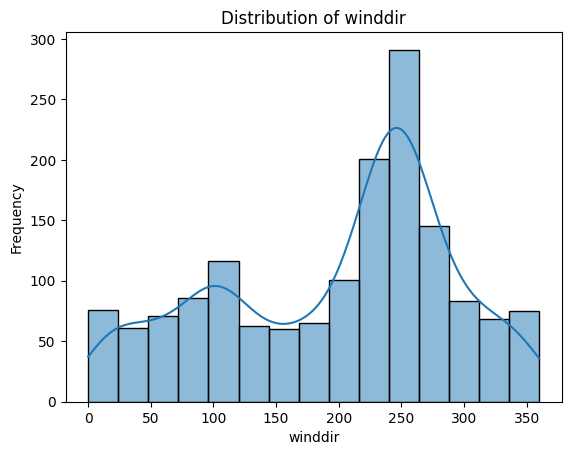

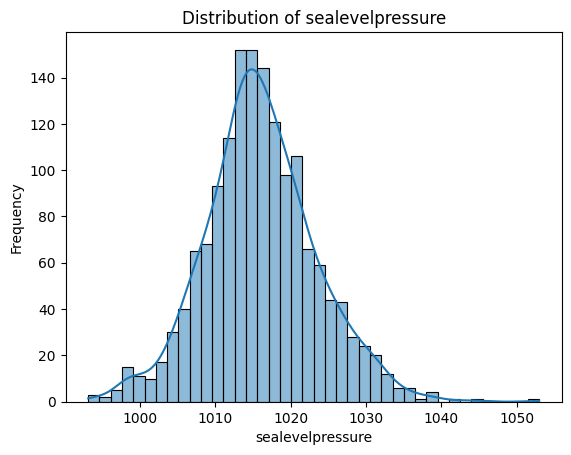

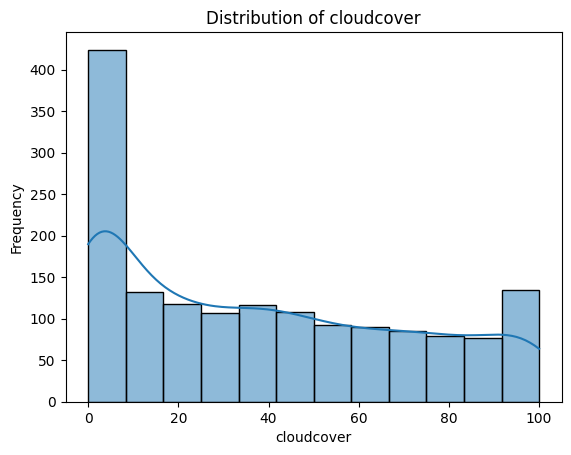

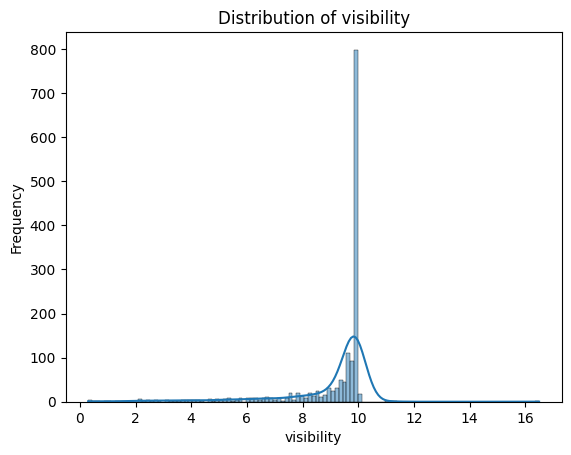

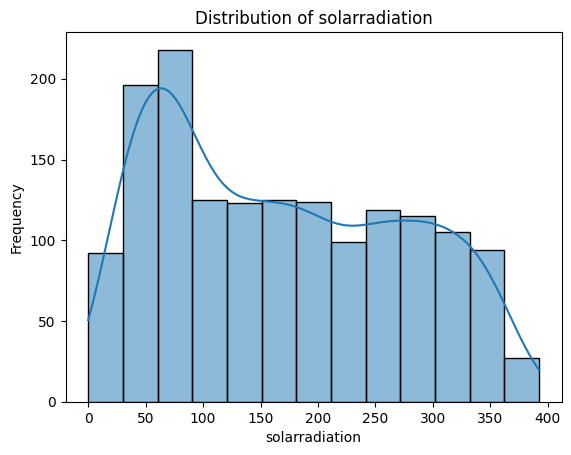

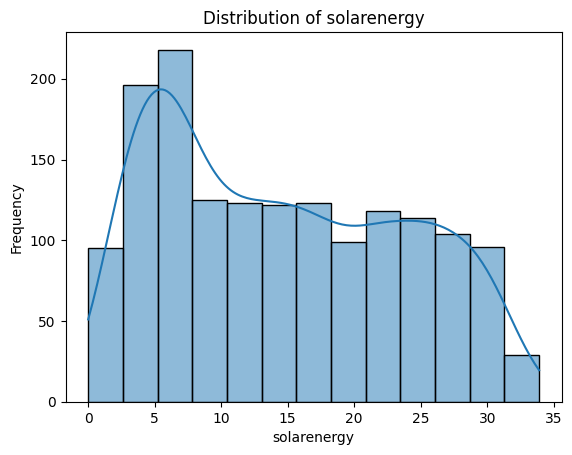

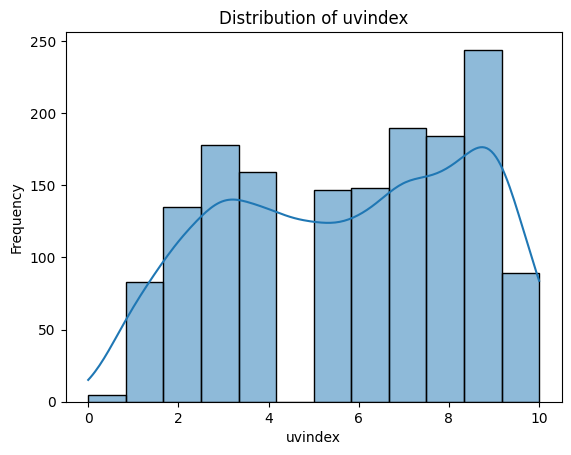

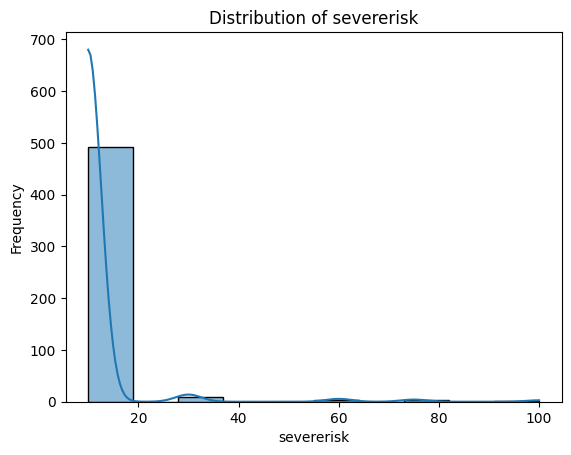

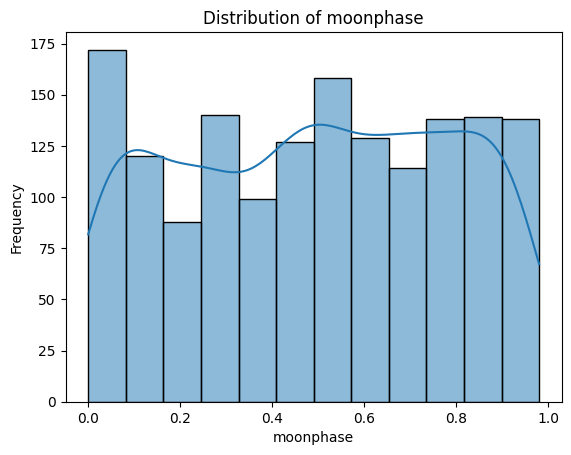

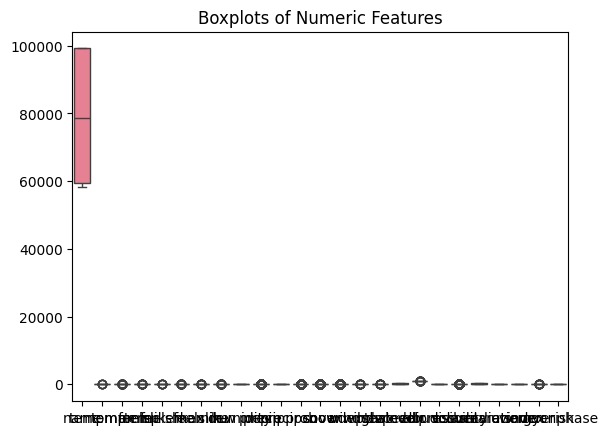

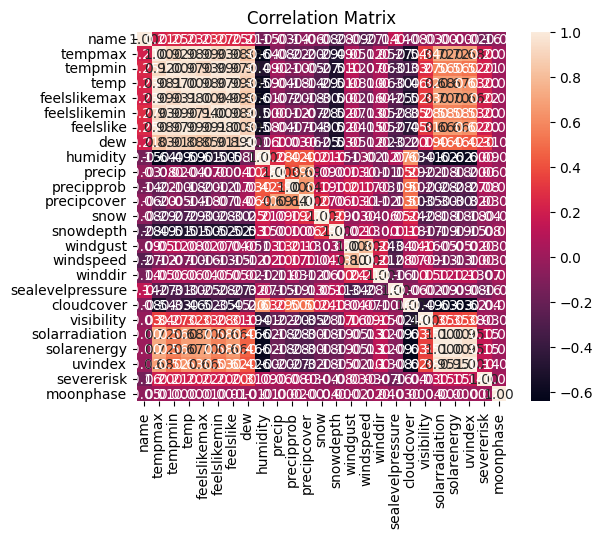

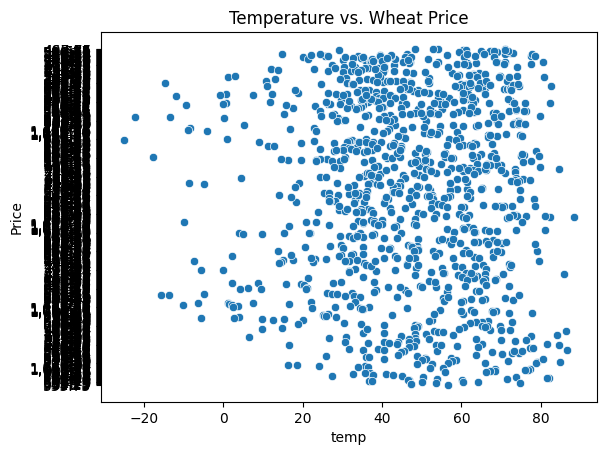

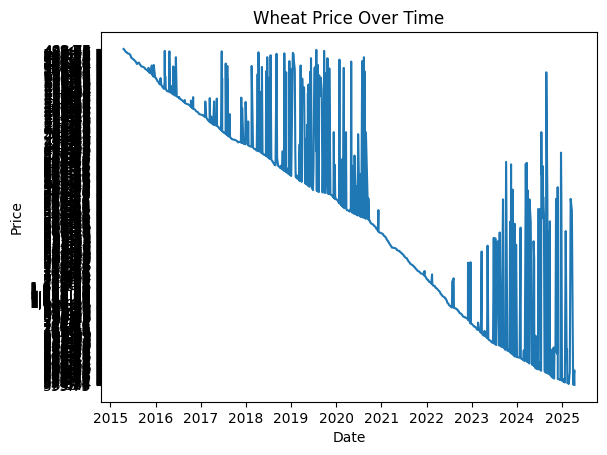

In [5]:
from pyspark.sql.functions import col, isnan, when, count
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#strip column names
old_cols = merged.columns
new_cols = [c.replace('.', '').replace(' ', '_') for c in old_cols]
merged_clean = merged.toDF(*new_cols)

#check for nulls
null_exprs = []
for c, dtype in merged_clean.dtypes:
    cond = col(c).isNull() | (isnan(col(c)) if dtype in ("double","float") else col(c).isNull())
    null_exprs.append(count(when(cond, col(c))).alias(f"{c}_missing"))

merged_clean.select(*null_exprs).show(truncate=False)

#Summary statistics
merged_clean.describe().show(truncate=False)

#move to pandas to plot
pdf = merged_clean.sample(False, 0.1, seed=42).toPandas()

# auto‑detect numeric columns
numeric_cols = [c for c, dtype in merged_clean.dtypes
                if dtype in ("double","float","int","bigint")]

#Univariate histograms
for c in numeric_cols:
    sns.histplot(pdf[c].dropna(), kde=True)
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.show()

#Boxplots of numeric features
sns.boxplot(data=pdf[numeric_cols])
plt.title("Boxplots of Numeric Features")
plt.show()

#Correlation heatmap
corr = pdf[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()

#Scatterplot (temp vs. Price)
if "temp" in pdf.columns and "Price" in pdf.columns:
    sns.scatterplot(x="temp", y="Price", data=pdf)
    plt.title("Temperature vs. Wheat Price")
    plt.show()

# 8) Time‑series of Price
if "Date" in pdf.columns and "Price" in pdf.columns:
    pdf["Date"] = pd.to_datetime(pdf["Date"])
    pdf = pdf.sort_values("Date")

    # raw line plot
    sns.lineplot(x="Date", y="Price", data=pdf)
    plt.title("Wheat Price Over Time")
    plt.show()




Feature Engineering/Preprocessing Steps

In [ ]:
#one hot encode zip codes
#create lagged features?
#impute price nulls with most previous price data
#print/cast types, clean column names
#standard scale?
#Traintest split
#PCA potentially? 
        #probably not - we are using trees, and we need features to be interperetable.
#drop irrelavant rows
#encode percitiation types